In [2]:
from langgraph.graph import StateGraph
from typing import TypedDict
from IPython.display import Image, display

In [26]:
class ConditionState(TypedDict):
    number1: int
    number2: int
    operator: str
    result: int

In [27]:
def add_node(state: ConditionState) -> ConditionState:
    """加法节点"""
    state["result"] = state["number1"] + state["number2"]
    return state

In [28]:
def subtract_node(state: ConditionState) -> ConditionState:
    """减法节点"""
    state["result"] = state["number1"] - state["number2"]
    return state

In [29]:
def condition_node(state: ConditionState) -> str:
    if state["operator"] == "+":
        return "add_node"
    elif state["operator"] == "-":
        return "subtract_node"

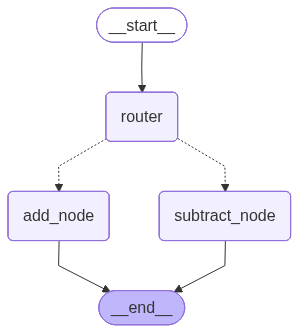

In [37]:
from langgraph.constants import START, END

graph = StateGraph(ConditionState)

graph.add_node("add_node", add_node)
graph.add_node("subtract_node", subtract_node)
# state透传，add_node的第二个参数是一个Runnable, callable or dict
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    condition_node,
    {
        # 如果结果是add_node，就传到 add_node 这个node上
        "add_node": "add_node",
        "subtract_node": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

graph.compile()

"""tips
可以直接用start做第一个条件分支，langgraph是支持的
"""

In [33]:
app = graph.compile()

In [34]:
app.invoke({"number1": 1, "number2": 2, "operator": "-"})

{'number1': 1, 'number2': 2, 'operator': '-', 'result': -1}